In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import arabic_reshaper
from bidi.algorithm import get_display

def fix_farsi(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

In [3]:
df = pd.read_csv('../data/raw/Dollar_Rial_Price_Dataset.csv')
df.head()

,Unnamed: 0,Date,Persian_Date,Open,Low,High,Close
0,0,11/27/2011,1390/09/06,"13,700","13,700","13,700","13,700"
1,1,11/28/2011,1390/09/07,"13,440","13,440","13,440","13,440"
2,2,11/29/2011,1390/09/08,"13,350","13,350","13,350","13,350"
3,3,11/30/2011,1390/09/09,"13,400","13,400","13,400","13,400"
4,4,12/1/2011,1390/09/10,"13,500","13,500","13,500","13,500"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3310 entries, 0 to 3309
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    3310 non-null   int64
 1   Date          3310 non-null   str  
 2   Persian_Date  3310 non-null   str  
 3   Open          3310 non-null   str  
 4   Low           3310 non-null   str  
 5   High          3310 non-null   str  
 6   Close         3310 non-null   str  
dtypes: int64(1), str(6)
memory usage: 181.1 KB


حذف ستون اضافی Unnamed: 0

In [5]:
df = df.drop(columns=['Unnamed: 0'])

# تبدیل ستون Date به فرمت تاریخ واقعی

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

# تبدیل ستون‌های قیمت به عدد

In [7]:
price_columns = ['Open', 'Low', 'High', 'Close']

for col in price_columns:
    df[col] = df[col].str.replace(',', '').astype(int)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3310 entries, 0 to 3309
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3310 non-null   datetime64[us]
 1   Persian_Date  3310 non-null   str           
 2   Open          3310 non-null   int64         
 3   Low           3310 non-null   int64         
 4   High          3310 non-null   int64         
 5   Close         3310 non-null   int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 155.3 KB


# مرتب‌سازی بر اساس تاریخ

In [9]:
df = df.sort_values('Date').reset_index(drop=True)

بررسی ردیف‌های تکراری

In [10]:
df.duplicated().sum()

np.int64(0)

# بررسی «شکاف‌های زمانی» (خیلی مهم برای سری زمانی)

In [11]:
date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
print("تعداد کل روزها در این بازه:", len(date_range))
print("تعداد رکوردهای موجود:", len(df))
print("تعداد روزهای بدون داده:", len(date_range) - len(df))

تعداد کل روزها در این بازه: 4239
تعداد رکوردهای موجود: 3310
تعداد روزهای بدون داده: 929


In [12]:
df['DayOfWeek'] = df['Date'].dt.day_name()
df['DayOfWeek'].value_counts()

DayOfWeek
Sunday       540
Monday       540
Wednesday    537
Tuesday      535
Saturday     535
Thursday     534
Friday        89
Name: count, dtype: int64

# تنظیم Date به‌عنوان ایندکس

In [13]:
df = df.set_index('Date')

ساخت بازه زمانی کامل و بازآرایی

In [14]:
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_range)

پر کردن مقادیر خالی با Forward Fill

In [15]:
df = df.ffill()

In [16]:
df.isnull().sum()

Persian_Date    0
Open            0
Low             0
High            0
Close           0
DayOfWeek       0
dtype: int64

In [17]:
df.shape

(4239, 6)

In [18]:
df['DayOfWeek'].value_counts()

DayOfWeek
Thursday     1099
Wednesday     718
Monday        601
Sunday        593
Tuesday       577
Saturday      561
Friday         90
Name: count, dtype: int64

# بازسازی درست DayOfWeek

In [19]:
df['DayOfWeek'] = df.index.day_name()

In [20]:
df['DayOfWeek'].value_counts()

DayOfWeek
Sunday       606
Monday       606
Tuesday      606
Wednesday    606
Thursday     605
Friday       605
Saturday     605
Name: count, dtype: int64

حذف ستون Persian_Date

In [21]:
df = df.drop(columns=['Persian_Date'])

In [22]:
df.columns.tolist()

['Open', 'Low', 'High', 'Close', 'DayOfWeek']

# ذخیره داده تمیزشده

In [23]:
df.to_csv('../data/processed/dollar_price_clean.csv')

# رسم نمودار روند قیمت (Close) طی زمان

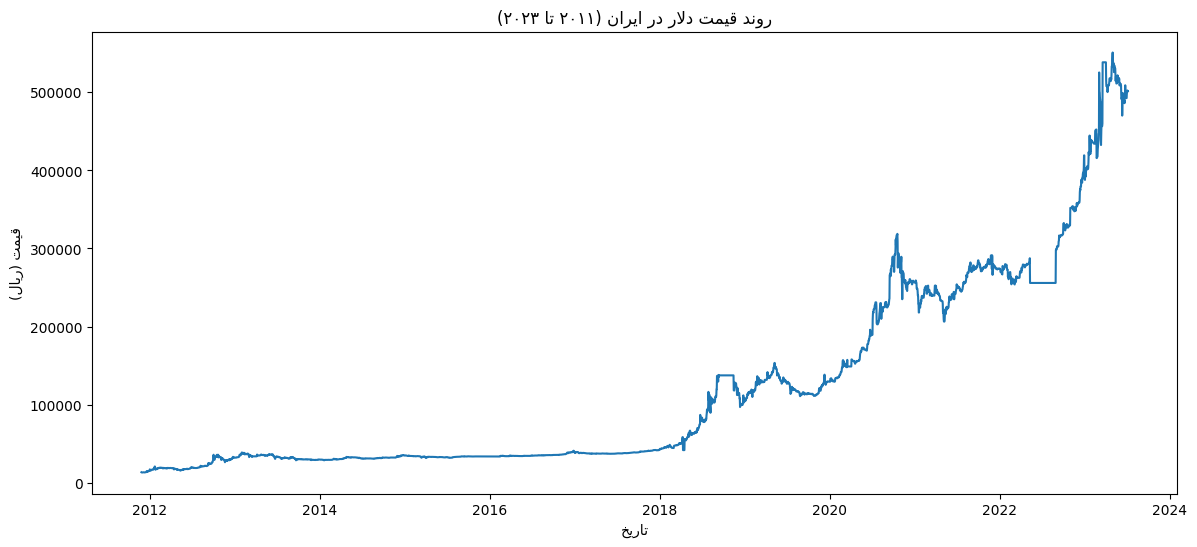

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'])
plt.title(fix_farsi('روند قیمت دلار در ایران (۲۰۱۱ تا ۲۰۲۳)'))
plt.xlabel(fix_farsi('تاریخ'))
plt.ylabel(fix_farsi('قیمت (ریال)'))
plt.show()

In [25]:
df['Close'].diff().eq(0).groupby(df.index.to_period('M')).sum().sort_values(ascending=False).head(10)

2022-07    31
2018-10    31
2022-06    30
2022-08    29
2022-05    23
2018-09    19
2018-11    18
2013-03    16
2020-03    16
2023-03    16
Freq: M, Name: Close, dtype: int64

In [26]:
same_as_prev = df['Close'].diff().eq(0)
groups = (~same_as_prev).cumsum()
run_length = same_as_prev.groupby(groups).sum()

top_runs = run_length.sort_values(ascending=False).head(5)
print(top_runs)

Close
2875    110
1904     62
355      18
2279     14
3030     14
Name: Close, dtype: int64


In [27]:
for g in run_length.sort_values(ascending=False).head(5).index :
    dates = df.index[groups == g]
    print(f"طول: {len(dates)} روز   |   از {dates.min().date()} تا {dates.max().date()}")

طول: 111 روز   |   از 2022-05-11 تا 2022-08-29
طول: 63 روز   |   از 2018-09-13 تا 2018-11-14
طول: 19 روز   |   از 2013-03-18 تا 2013-04-05
طول: 15 روز   |   از 2020-03-18 تا 2020-04-01
طول: 15 روز   |   از 2023-03-19 تا 2023-04-02


برگردیم به داده خام و تاریخ‌های اصلی رو بگیریم

In [28]:
df_raw_dates = pd.read_csv('../data/raw/Dollar_Rial_Price_Dataset.csv')
original_dates = set(pd.to_datetime(df_raw_dates['Date']))

df['Is_Imputed'] = ~df.index.isin(original_dates)

In [29]:
df['Is_Imputed'].sum()

np.int64(929)

ذخیره

In [30]:
df.to_csv('../data/processed/dollar_price_clean.csv')

In [31]:
df['Daily_Return'] = df['Close'].pct_change()

print("انحراف معیار بازده روزانه (کل داده، شامل شکاف‌ها):", df['Daily_Return'].std())
print("انحراف معیار بازده روزانه (فقط روزهای واقعی):", df[~df['Is_Imputed']]['Daily_Return'].std())

انحراف معیار بازده روزانه (کل داده، شامل شکاف‌ها): 0.017132486352818707
انحراف معیار بازده روزانه (فقط روزهای واقعی): 0.019380339448489766


دو تا شکاف بزرگ و غیرطبیعی (۲۰۱۸ و ۲۰۲۲) رو حذف می‌کنیم

In [32]:
mask_gap1 = (df.index >= '2018-09-13') & (df.index <= '2018-11-14')
mask_gap2 = (df.index >= '2022-05-11') & (df.index <= '2022-08-29')

df_final = df[~(mask_gap1 | mask_gap2)].copy()

In [33]:
print("تعداد ردیف قبل : ", len(df))
print("تعداد ردیف بعد :", len(df_final))

تعداد ردیف قبل :  4239
تعداد ردیف بعد : 4065


# نهایی کرددن Daily Return

In [34]:
df_final['Daily_Return'] = df_final['Close'].pct_change()

ذخیره نسخه نهایی

In [35]:
df_final.to_csv('../data/processed/dollar_price_final.csv')

# نمودار روند قیمت روی داده نهایی

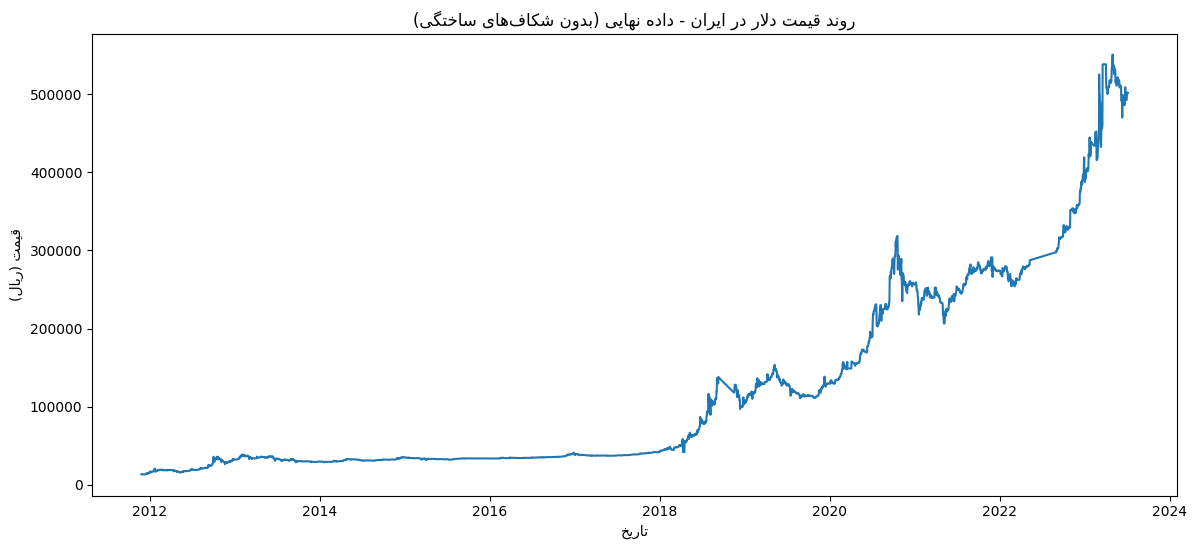

In [38]:
plt.figure(figsize=((14,6)))
plt.plot(df_final.index, df_final['Close'])
plt.title(fix_farsi('روند قیمت دلار در ایران - داده نهایی (بدون شکاف‌های ساختگی)'))
plt.xlabel(fix_farsi('تاریخ'))
plt.ylabel(fix_farsi('قیمت (ریال)'))
plt.show()